# Bayesian-CVaR ETF allocation with risk-timing overlays — FINAL Policy-C results (v2)

This notebook is adapted to the **Policy C split-state execution convention**:

- the optimizer's turnover/regularisation anchor is the **previous target**;
- actual trading starts from the **previous executed holdings**;
- partial execution moves executed holdings toward the new target;
- transaction cost is `c_bps × gross L1 traded notional` (buys + sells);
- returns are booked on every actually held name, including names leaving the feasible set;
- the default headline overlay leaves separate exposure-overlay changes uncharged, with an optional sensitivity switch below.

`Restart & Run All` re-runs the core model arms with `--skip-postprocess`, because this notebook itself performs the downstream result construction. It validates `run_metadata.json` and `execution_audit.csv` before using the outputs.


In [17]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import sys, json, inspect
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import norm, skew, kurtosis
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt, matplotlib.dates as mdates


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, start.parent, start.parent.parent]
    for c in candidates:
        if (c / "scripts").is_dir() and (c / "datasets").is_dir():
            return c
    raise FileNotFoundError(
        "Could not find project root containing scripts/ and datasets/. "
        "Place this notebook in the framework root (or one folder below it)."
    )

ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import report_style as rs; rs.apply()
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 40)

DATA = ROOT / "results"
DAILY_FILE = ROOT / "datasets" / "excel" / "new_etf_returns.csv"
RF = 0.02; CAP = 0.12; LB_Y = 3; SEED = 42
KMIN, KMAX = 0.30, 1.00; SPAN, TARGET_VOL = 21, 0.12; TOP_K = 16
N_TRIALS = 64
POLICY_C_ID = "policy_C_split"
CHARGE_EXPOSURE_COSTS = False
EXPOSURE_COST_RATE = 0.001
INCLUDE_COMPANION_STRATEGY = False
CAT = ["#2E86C1","#3CA370","#F5A623","#C94C4C","#163A5F","#6FB7E0","#7FC9A6","#F7C271",
       "#D98A8A","#4E6E8E","#A6CEE3","#8E5BA6","#B5BD68","#E08AB0","#56A8A8","#C08457"]
print("project root:", ROOT)
print("Policy C expected:", POLICY_C_ID)
print("charge exposure-overlay costs:", CHARGE_EXPOSURE_COSTS)


project root: /Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-
Policy C expected: policy_C_split
charge exposure-overlay costs: False


## Step 0 — re-run the numerical model under Policy C

The updated `run.py` writes the core numerical result first and can skip its own heavy report-generation stage with `--skip-postprocess`. That avoids treating an optional plotting/report failure as if the portfolio model itself failed.

Before running, this notebook checks that all five Policy-C source files are installed, including the two backtesting files that the earlier small update bundle did not include. The full subprocess output is saved under `results/_policy_c_logs/` if a configuration fails.


In [18]:
print("Using project root:", ROOT)
print("Results directory:", DATA)


Using project root: /Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-
Results directory: /Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results


In [19]:
REGENERATE = True

RUNS = [
    ("main_dyn_off.yaml", "main_dyn_off"),
    ("main_dyn_on.yaml", "main_dyn_on"),
    ("main_dyn_strong.yaml", "main_dyn_strong"),
    ("advanced_smart_bayesian.yaml", "advanced_smart_bayesian"),
]

REQUIRED_POLICY_C_FILES = [
    ROOT / "scripts" / "runs" / "run.py",
    ROOT / "scripts" / "executions" / "base.py",
    ROOT / "scripts" / "executions" / "accounting.py",
    ROOT / "scripts" / "backtesting" / "engine_integration.py",
    ROOT / "scripts" / "backtesting" / "walk_forward_engine.py",
]


def policy_c_preflight():
    missing = [str(p.relative_to(ROOT)) for p in REQUIRED_POLICY_C_FILES if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing Policy-C source files: " + ", ".join(missing))

    from scripts.backtesting.engine_integration import results_by_nested_backtest_engine
    from scripts.backtesting.walk_forward_engine import PortfolioWalkForwardBacktestEngine
    sig_int = inspect.signature(results_by_nested_backtest_engine)
    sig_sel = inspect.signature(PortfolioWalkForwardBacktestEngine.select)
    need = {"w_optimizer_reference", "w_execution_state"}
    if not need.issubset(sig_int.parameters):
        raise RuntimeError(
            "engine_integration.py is still the old version. Replace it with the Policy-C version; "
            f"current parameters are: {list(sig_int.parameters)}"
        )
    if not need.issubset(sig_sel.parameters):
        raise RuntimeError(
            "walk_forward_engine.py is still the old version. Replace it with the Policy-C version; "
            f"current parameters are: {list(sig_sel.parameters)}"
        )

    run_text = (ROOT / "scripts" / "runs" / "run.py").read_text(encoding="utf-8")
    if 'POLICY_C_ID = "policy_C_split"' not in run_text:
        raise RuntimeError("scripts/runs/run.py is not the Policy-C version")
    if "--skip-postprocess" not in run_text:
        raise RuntimeError("scripts/runs/run.py is an older Policy-C draft without --skip-postprocess")
    print("Policy-C source preflight: OK")


def assert_policy_c_result(arm: str):
    folder = DATA / arm
    meta_path = folder / "run_metadata.json"
    audit_path = folder / "execution_audit.csv"
    if not meta_path.exists():
        raise FileNotFoundError(f"{arm}: missing run_metadata.json; run is incomplete or from old code")
    meta = json.loads(meta_path.read_text())
    if meta.get("execution_policy") != POLICY_C_ID:
        raise RuntimeError(f"{arm}: expected {POLICY_C_ID}, found {meta.get('execution_policy')!r}")
    if meta.get("optimizer_turnover_reference") != "previous_target":
        raise RuntimeError(f"{arm}: optimizer anchor is not previous_target")
    if meta.get("economic_trade_start") != "previous_executed_holdings":
        raise RuntimeError(f"{arm}: execution does not start from previous executed holdings")
    if not audit_path.exists():
        raise FileNotFoundError(f"{arm}: missing execution_audit.csv")
    a = pd.read_csv(audit_path)
    if a.empty:
        raise RuntimeError(f"{arm}: execution_audit.csv is empty")
    resid = pd.to_numeric(a["cost_identity_residual"], errors="coerce").abs().max()
    if pd.notna(resid) and resid > 1e-10:
        raise RuntimeError(f"{arm}: cost identity residual too large: {resid:.3e}")
    return meta, a

policy_c_preflight()

if REGENERATE:
    import subprocess, os, time
    env = os.environ.copy()
    env["PYTHONPATH"] = str(ROOT)
    log_dir = DATA / "_policy_c_logs"
    log_dir.mkdir(parents=True, exist_ok=True)
    t0 = time.time()

    for cfg, arm in RUNS:
        cmd = [sys.executable, "-m", "scripts.runs.run", "-c", cfg, "--skip-postprocess"]
        print(f"running Policy C core: {cfg} ...", flush=True)
        r = subprocess.run(cmd, cwd=str(ROOT), env=env, capture_output=True, text=True)
        full_log = (r.stdout or "") + "\n\n--- STDERR ---\n" + (r.stderr or "")
        log_path = log_dir / f"{arm}.log"
        log_path.write_text(full_log, encoding="utf-8", errors="replace")

        if r.returncode != 0:
            print(f"FAILED command: {' '.join(cmd)}")
            print("cwd:", ROOT)
            print("full log:", log_path)
            print("\nLAST 12000 CHARACTERS OF PROCESS OUTPUT:\n")
            print(full_log[-12000:])
            raise RuntimeError(
                f"core Policy-C model run failed for {cfg}. "
                f"The complete underlying traceback is in {log_path}."
            )

        meta, audit = assert_policy_c_result(arm)
        print(
            f"  done: {arm} | months={len(audit)} | "
            f"max cost residual={audit.cost_identity_residual.abs().max():.2e} | "
            f"cost={meta.get('transaction_cost_bps_per_traded_unit', float('nan')):.1f} bp/gross unit"
        )

    print(f"Policy-C core re-run complete in {time.time()-t0:.0f}s")
else:
    print("REGENERATE=False -> validating existing Policy-C results")
    for _, arm in RUNS:
        if (DATA / arm).exists():
            _, audit = assert_policy_c_result(arm)
            print(f"  validated: {arm} ({len(audit)} execution months)")


Policy-C source preflight: OK
running Policy C core: main_dyn_off.yaml ...
  done: main_dyn_off | months=83 | max cost residual=0.00e+00 | cost=10.0 bp/gross unit
running Policy C core: main_dyn_on.yaml ...
  done: main_dyn_on | months=83 | max cost residual=0.00e+00 | cost=10.0 bp/gross unit
running Policy C core: main_dyn_strong.yaml ...
  done: main_dyn_strong | months=83 | max cost residual=0.00e+00 | cost=10.0 bp/gross unit
running Policy C core: advanced_smart_bayesian.yaml ...
  done: advanced_smart_bayesian | months=83 | max cost residual=0.00e+00 | cost=10.0 bp/gross unit
Policy-C core re-run complete in 2723s


## 1. Load the (freshly produced) base arms, derive overlays, build benchmarks

In [20]:
PRIMARY_STATIC = "main_dyn_off"
PRIMARY_DYNAMIC = "main_dyn_strong"
SMART_BAYESIAN = "advanced_smart_bayesian"
SMART_STRATEGY = "strategy_smart_liquidity_weighted"
DATA = ROOT / "results"


def load_pnl_full(arm):
    p = pd.read_csv(DATA/arm/"pnl.csv"); c = p.columns[0]; p[c] = pd.to_datetime(p[c])
    return p.set_index(c)["Returns"].astype(float)


def load_pnl(arm):
    return load_pnl_full(arm).iloc[1:]


def load_weights(arm, state="executed"):
    """Load Policy-C weights.

    state='executed' is the economic portfolio actually held and is the correct input for
    realised-volatility reconstruction.  target/anchor are available for diagnostics.
    """
    preferred = {
        "executed": ["executed_weights", "weights"],
        "target": ["target_weights"],
        "anchor": ["optimizer_anchor_weights"],
    }
    if state not in preferred:
        raise ValueError("state must be executed, target, or anchor")
    xl = pd.ExcelFile(DATA/arm/"weights.xlsx"); out = {}
    for sh in xl.sheet_names:
        d = xl.parse(sh)
        col = next((x for x in preferred[state] if x in d.columns), None)
        if col is None:
            continue
        key_col = "Key" if "Key" in d.columns else d.columns[0]
        w = pd.to_numeric(d[col], errors="coerce").fillna(0.0)
        s = pd.Series(w.values, index=d[key_col].astype(str).values)
        s = s[s.abs() > 1e-12]
        if not s.empty:
            # For the volatility signal we want risky-sleeve composition.  In the core run
            # executed risky mass should be ~1; normalization also makes the intent explicit.
            total = float(s.sum())
            if total > 1e-12:
                s = s / total
            try:
                out[pd.to_datetime(sh)] = s
            except Exception:
                pass
    return dict(sorted(out.items()))


# Actual executed book under Policy C; do not reconstruct realised risk from an unfilled target.
W_strong = load_weights(PRIMARY_DYNAMIC, state="executed")
r_strong_full = load_pnl_full(PRIMARY_DYNAMIC)
idx = r_strong_full.index

_need = set()
for arm in [PRIMARY_STATIC, PRIMARY_DYNAMIC, SMART_BAYESIAN]:
    p = DATA / arm / "real.csv"
    if p.exists():
        _need |= set(pd.read_csv(p, nrows=0).columns) - {"Unnamed: 0"}
if INCLUDE_COMPANION_STRATEGY:
    p = DATA / SMART_STRATEGY / "real.csv"
    if p.exists():
        _need |= set(pd.read_csv(p, nrows=0).columns) - {"Unnamed: 0"}
for w in W_strong.values():
    _need |= set(w.index)
_need.add("SPY")


def daily_simple():
    head = pd.read_csv(DAILY_FILE, nrows=0).columns
    use = ["Date"] + [c for c in head if c in _need]
    df = pd.read_csv(DAILY_FILE, usecols=use); df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    return np.exp(df.apply(pd.to_numeric, errors="coerce")) - 1.0

DLY = daily_simple()

reb = list(W_strong.keys()); parts = []
for i in range(len(reb)-1):
    d0, d1 = reb[i], reb[i+1]
    w = W_strong[d0]
    cc = [t for t in w.index if t in DLY.columns]
    missing_held = [t for t in w.index if t not in DLY.columns and abs(float(w[t])) > 1e-12]
    if missing_held:
        raise RuntimeError(f"Executed holdings missing from daily-return panel at {d0.date()}: {missing_held[:20]}")
    win = DLY.loc[(DLY.index > d0) & (DLY.index <= d1), cc].fillna(0.0)
    if not win.empty:
        parts.append(pd.Series(win.values @ w.reindex(cc).fillna(0.0).values, index=win.index))

port_daily = pd.concat(parts).sort_index()
va = port_daily.rolling(SPAN, min_periods=10).std()*np.sqrt(252)
k_rv = pd.Series({
    idx[j]: (
        float(np.clip(TARGET_VOL/va.asof(idx[j-1]), KMIN, KMAX))
        if (va.asof(idx[j-1]) == va.asof(idx[j-1]) and va.asof(idx[j-1]) > 0)
        else KMAX
    )
    for j in range(1, len(idx))
})

rs_ret = r_strong_full.iloc[1:]
fc = pd.read_csv(DATA/PRIMARY_DYNAMIC/"forecast_risk.csv"); fc["date"] = pd.to_datetime(fc["date"])
cv = fc.set_index("date")["cvar_model"].astype(float).reindex(rs_ret.index)
k_mc = (cv.expanding(min_periods=6).median().bfill()/cv).clip(KMIN, KMAX)
k_rv = k_rv.reindex(rs_ret.index)
k_comb = (k_rv*k_mc).clip(KMIN, KMAX)


def overlay_return(k, risky_net_return, charge_exposure_costs=False):
    k = pd.Series(k, dtype=float).reindex(risky_net_return.index)
    out = k*risky_net_return + (1-k)*RF/12
    if charge_exposure_costs:
        overlay_turnover = k.diff().abs().fillna(0.0)
        out = out - EXPOSURE_COST_RATE*overlay_turnover
    return out

r_vt   = overlay_return(k_rv, rs_ret, CHARGE_EXPOSURE_COSTS)
r_mc   = overlay_return(k_mc, rs_ret, CHARGE_EXPOSURE_COSTS)
r_comb = overlay_return(k_comb, rs_ret, CHARGE_EXPOSURE_COSTS)


def solve(mu, cov, kind):
    n = len(mu); x0 = np.ones(n)/n; bnds = [(0.0, CAP)]*n; cons = [{"type":"eq","fun":lambda w: w.sum()-1.0}]
    obj = (lambda w: float(w@cov@w)) if kind == "minvar" else (lambda w: -float((mu@w - RF/12)/np.sqrt(max(w@cov@w,1e-12))))
    r = minimize(obj, x0, method="SLSQP", bounds=bnds, constraints=cons, options={"maxiter":300,"ftol":1e-9})
    w = r.x if (r.success and np.all(np.isfinite(r.x))) else x0; w = np.clip(w, 0, CAP)
    return w/w.sum() if w.sum() > 0 else x0


def benchmarks():
    real = pd.read_csv(DATA/PRIMARY_STATIC/"real.csv"); real["Unnamed: 0"] = pd.to_datetime(real["Unnamed: 0"])
    real = real.set_index("Unnamed: 0"); real_s = np.exp(real)-1.0; dts = list(real.index)
    ew, msr, mv = [], [], []
    for i in range(1, len(dts)):
        rd, bd = dts[i], dts[i-1]; elig = real_s.loc[rd].dropna().index.tolist()
        win = DLY.loc[(DLY.index > bd - pd.DateOffset(years=LB_Y)) & (DLY.index <= bd)]
        good = [t for t in elig if t in win.columns and win[t].notna().sum() >= 250] or [t for t in elig if t in win.columns]
        if len(good) < 5: continue
        rr = real_s.loc[rd, good].astype(float); W = win[good].dropna(how="all"); mu = W.mean().values*21.0
        cov = (LedoitWolf().fit(np.nan_to_num(W.values)).covariance_ if W.shape[0] > len(good) else np.cov(np.nan_to_num(W.values), rowvar=False))*21.0
        cov = np.atleast_2d(cov)
        ew.append((rd, float((np.ones(len(good))/len(good)) @ rr.values)))
        msr.append((rd, float(solve(mu, cov, "ms") @ rr.values)))
        mv.append((rd, float(solve(mu, cov, "minvar") @ rr.values)))
    return {"Benchmark 1/N": pd.Series(dict(ew)),
            "Benchmark Markowitz max-Sharpe": pd.Series(dict(msr)),
            "Benchmark Markowitz min-variance": pd.Series(dict(mv))}

arms = {
    "Static (no overlay)": load_pnl(PRIMARY_STATIC),
    "Dynamic base": rs_ret,
    "+ Realized-vol overlay": r_vt,
    "+ Model-CVaR overlay": r_mc,
    "+ Combined (managed)": r_comb,
}
if (DATA / SMART_BAYESIAN / "pnl.csv").exists():
    arms["+ Advanced smart Bayesian"] = load_pnl(SMART_BAYESIAN)
if INCLUDE_COMPANION_STRATEGY and (DATA / SMART_STRATEGY / "pnl.csv").exists():
    arms["+ Smart strategy"] = load_pnl(SMART_STRATEGY)
arms.update(benchmarks())

print("arms built (months each):", {k: len(v) for k, v in arms.items()})
print(
    f"exposure k: realized-vol median {k_rv.median():.2f}, model-CVaR median {k_mc.median():.2f}, "
    f"combined median {k_comb.median():.2f} | corr(k_rv,k_mc)={np.corrcoef(k_rv,k_mc)[0,1]:+.2f}"
)
print("overlay exposure costs charged:", CHARGE_EXPOSURE_COSTS)


arms built (months each): {'Static (no overlay)': 83, 'Dynamic base': 83, '+ Realized-vol overlay': 83, '+ Model-CVaR overlay': 83, '+ Combined (managed)': 83, '+ Advanced smart Bayesian': 83, 'Benchmark 1/N': 83, 'Benchmark Markowitz max-Sharpe': 83, 'Benchmark Markowitz min-variance': 83}
exposure k: realized-vol median 0.59, model-CVaR median 0.92, combined median 0.44 | corr(k_rv,k_mc)=+0.33
overlay exposure costs charged: False


## 2. Metrics table — all strategies, all ratios

Monthly excess returns (RF = 2%). `Beta`/`Treynor` use SPY; `PSR`/`DSR` are the Probabilistic and
Deflated Sharpe ratios (DSR dispersion over the strategy arms only, conservative N = 40 trials).

In [21]:
spy = DLY["SPY"]
full_idx = list(load_pnl_full(PRIMARY_STATIC).index)
def spy_monthly(ix):
    out = {}
    for j in range(1, len(ix)):
        d0, d1 = ix[j-1], ix[j]; w = spy[(spy.index > d0) & (spy.index <= d1)]
        out[d1] = float(np.prod(1+w.values)-1) if len(w) else np.nan
    return pd.Series(out)
MKT = spy_monthly(full_idx)

def ann_sharpe(r): r = np.asarray(r, float); ex = r - RF/12; return ex.mean()/ex.std(ddof=1)*np.sqrt(12)
def max_dd(r): r = np.asarray(r, float); eq = np.cumprod(1+r); return float((eq/np.maximum.accumulate(eq)-1).min())

def metrics(r):
    r = r.dropna(); rv = np.asarray(r, float); n = len(rv); tot = float(np.prod(1+rv)-1); ann = (1+tot)**(12/n)-1
    vol = rv.std(ddof=1)*np.sqrt(12); ex = rv - RF/12; sh = ex.mean()/ex.std(ddof=1)*np.sqrt(12)
    dn = rv[rv < 0]; ddv = dn.std(ddof=1)*np.sqrt(12) if len(dn) > 1 else np.nan
    sor = (ann - RF)/ddv if (ddv and ddv > 0) else np.nan
    eq = np.cumprod(1+rv); dr = eq/np.maximum.accumulate(eq)-1; mdd = float(dr.min())
    cal = ann/abs(mdd) if mdd < 0 else np.nan; v95 = np.percentile(rv, 5); cv = float(rv[rv <= v95].mean())
    m = MKT.reindex(r.index); beta = np.cov(rv, m.values, ddof=1)[0,1]/np.var(m.values, ddof=1)
    treyn = (ann - RF)/beta*100; ddev = np.sqrt(np.mean(np.minimum(rv,0)**2))*np.sqrt(12)*100
    pain = -dr.mean(); painr = (ann - RF)/pain if pain > 0 else np.nan; mad = np.mean(np.abs(rv - rv.mean()))*100
    return dict(Cumul=tot*100, Ann=ann*100, Vol=vol*100, Sharpe=sh, Sortino=sor, MaxDD=mdd*100, Calmar=cal,
                CVaR95=cv*100, Beta=beta, Treynor=treyn, DownDev=ddev, PainRatio=painr, MAD=mad,
                _sk=float(skew(rv)), _ku=float(kurtosis(rv, fisher=False)), _n=n, _srm=float(ex.mean()/ex.std(ddof=1)))

def psr(srm, star, n, sk, ku):
    den = np.sqrt(max(1 - sk*srm + (ku-1)/4*srm**2, 1e-12)); return float(norm.cdf((srm - star)*np.sqrt(n-1)/den))

ms = {k: metrics(v) for k, v in arms.items()}
g = 0.5772156649
var_srm = np.var(np.array([m["Sharpe"] for k, m in ms.items() if not k.startswith("Benchmark")])/np.sqrt(12), ddof=1)
z = (1-g)*norm.ppf(1-1/N_TRIALS) + g*norm.ppf(1-1/(N_TRIALS*np.e)); star = float(np.sqrt(max(var_srm,0))*z)

cols = ["Cumul","Ann","Vol","Sharpe","Sortino","MaxDD","Calmar","CVaR95","Beta","Treynor","DownDev","PainRatio","MAD"]
rows = {}
for k, m in ms.items():
    d = {c: m[c] for c in cols}
    d["PSR"] = psr(m["_srm"], 0.0, m["_n"], m["_sk"], m["_ku"])*100
    d["DSR"] = psr(m["_srm"], star, m["_n"], m["_sk"], m["_ku"])*100
    rows[k] = d
TBL = pd.DataFrame(rows).T[cols + ["PSR","DSR"]].round(2)
TBL.columns = ["Cumul %","Ann %","Vol %","Sharpe","Sortino","MaxDD %","Calmar","CVaR95 %","Beta",
               "Treynor %","DownDev %","Pain ratio","MAD %","PSR %","DSR %"]
TBL


,Cumul %,Ann %,Vol %,Sharpe,Sortino,MaxDD %,Calmar,CVaR95 %,Beta,Treynor %,DownDev %,Pain ratio,MAD %,PSR %,DSR %
Static (no overlay),163.41,15.03,21.32,0.67,1.07,-16.03,0.94,-11.21,0.86,15.16,12.36,3.85,4.82,95.91,86.87
Dynamic base,163.20,15.02,21.19,0.67,1.05,-15.95,0.94,-11.22,0.85,15.31,12.29,3.86,4.78,95.95,86.99
+ Realized-vol overlay,117.15,11.86,11.65,0.85,1.87,-9.76,1.22,-4.61,0.46,21.54,5.82,5.57,2.72,98.90,95.03
+ Model-CVaR overlay,135.75,13.20,17.05,0.70,1.09,-15.11,0.87,-8.89,0.65,17.32,9.93,4.45,3.85,96.34,88.05
+ Combined (managed),107.89,11.16,10.31,0.89,1.95,-9.76,1.14,-4.07,0.39,23.28,4.99,6.65,2.36,99.21,96.11
+ Advanced smart Bayesian,160.12,14.82,15.41,0.85,1.32,-17.97,0.82,-8.56,0.76,16.93,9.37,4.13,3.48,98.16,93.30
Benchmark 1/N,98.35,10.41,14.44,0.62,0.81,-21.36,0.49,-8.71,0.77,10.91,9.31,1.91,3.15,93.71,82.70
Benchmark Markowitz max-Sharpe,26.02,3.40,5.57,0.27,0.26,-15.45,0.22,-3.85,0.22,6.23,4.06,0.36,1.08,75.03,53.08
Benchmark Markowitz min-variance,14.61,1.99,1.68,-0.01,-0.00,-5.18,0.38,-1.30,0.06,-0.15,1.26,-0.01,0.32,49.20,25.89


## 3. Statistical significance — paired bootstrap (5,000 resamples)

In [22]:
rng = np.random.default_rng(SEED); B = 5000
def boot(base, treat, lbl):
    j = base.index.intersection(treat.index); a, b = base.loc[j].values, treat.loc[j].values; n = len(j)
    shd = np.empty(B); ddd = np.empty(B)
    for k in range(B):
        ix = rng.integers(0, n, n); shd[k] = ann_sharpe(b[ix]) - ann_sharpe(a[ix]); ddd[k] = max_dd(b[ix]) - max_dd(a[ix])
    print(f"  {lbl:26s} dSharpe={ann_sharpe(b)-ann_sharpe(a):+.3f}  P(better)={float((shd>0).mean()):.3f}   "
          f"dMaxDD={max_dd(b)-max_dd(a):+.3f}  P(shallower)={float((ddd>0).mean()):.3f}")
print("Paired bootstrap (5000), treatment = Combined (managed)")
boot(arms["+ Realized-vol overlay"], arms["+ Combined (managed)"], "vs Realized-vol overlay")
boot(arms["Benchmark 1/N"],          arms["+ Combined (managed)"], "vs 1/N")
boot(arms["Dynamic base"],           arms["+ Combined (managed)"], "vs Dynamic base")
print(f"\nCombined PSR = {TBL.loc['+ Combined (managed)','PSR %']:.1f}%   DSR = {TBL.loc['+ Combined (managed)','DSR %']:.1f}%")


Paired bootstrap (5000), treatment = Combined (managed)
  vs Realized-vol overlay    dSharpe=+0.035  P(better)=0.694   dMaxDD=+0.000  P(shallower)=0.962
  vs 1/N                     dSharpe=+0.265  P(better)=0.805   dMaxDD=+0.116  P(shallower)=0.958
  vs Dynamic base            dSharpe=+0.214  P(better)=0.928   dMaxDD=+0.062  P(shallower)=1.000

Combined PSR = 99.2%   DSR = 96.1%


## 4. Cumulative performance

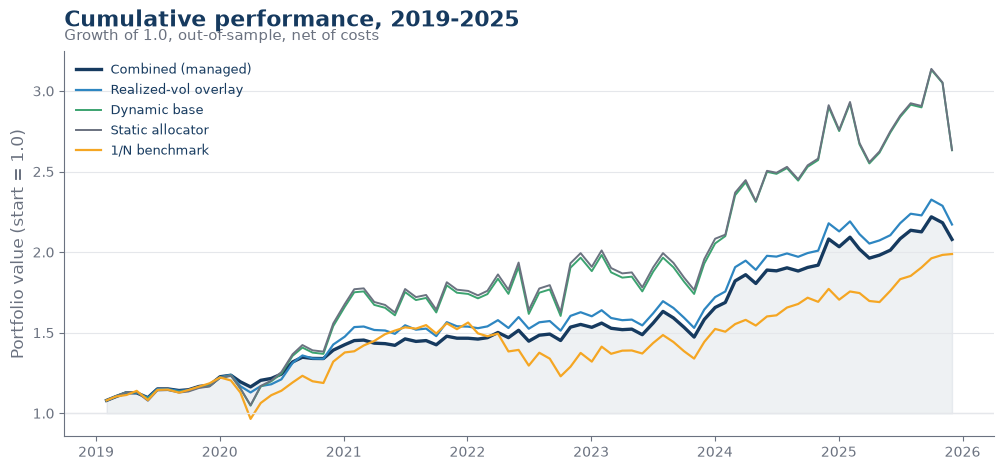

In [23]:
def oneN():
    real = pd.read_csv(DATA/PRIMARY_STATIC/"real.csv"); real["Unnamed: 0"] = pd.to_datetime(real["Unnamed: 0"])
    real = real.set_index("Unnamed: 0"); rsx = np.exp(real)-1.0
    return pd.Series({d: float(rsx.loc[d].dropna().mean()) for d in rsx.index[1:]})
series = {"Combined (managed)": (arms["+ Combined (managed)"], rs.NAVY, 2.4),
          "Realized-vol overlay": (arms["+ Realized-vol overlay"], rs.BLUE, 1.6),
          "Dynamic base": (arms["Dynamic base"], rs.GREEN, 1.4),
          "Static allocator": (arms["Static (no overlay)"], rs.GREY, 1.4),
          "1/N benchmark": (oneN(), rs.ORANGE, 1.6)}
fig, ax = plt.subplots(figsize=(12, 5))
for lbl, (r, col, lw) in series.items():
    eq = (1+r).cumprod()
    if lbl == "Combined (managed)": ax.fill_between(eq.index, 1, eq.values, color=rs.NAVY, alpha=0.07)
    ax.plot(eq.index, eq.values, color=col, lw=lw, label=lbl)
ax.axhline(1, color=rs.GRID, lw=1); ax.set_ylabel("Portfolio value (start = 1.0)"); ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
rs.title(ax, "Cumulative performance, 2019-2025", "Growth of 1.0, out-of-sample, net of costs")
plt.show()


## 5. Drawdowns (underwater curve)

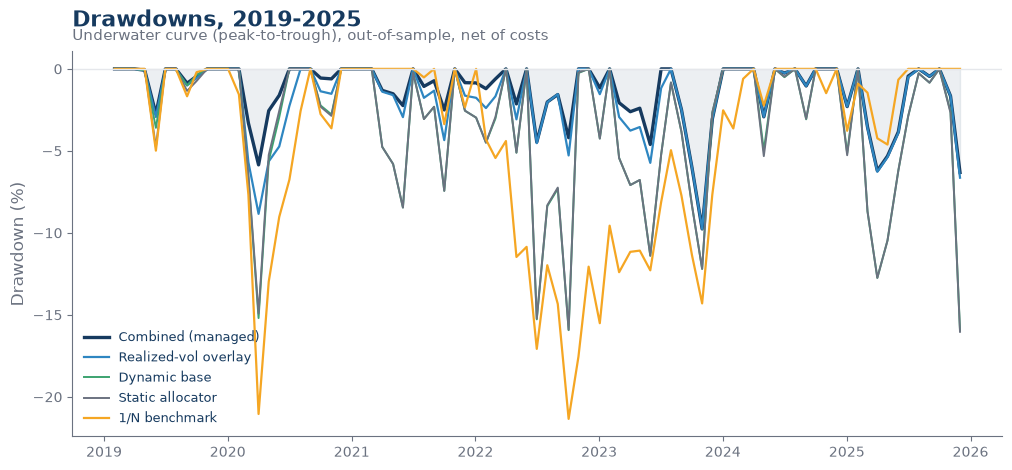

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
for lbl, (r, col, lw) in series.items():
    eq = (1+r).cumprod(); dd = (eq/eq.cummax()-1)*100
    if lbl == "Combined (managed)": ax.fill_between(dd.index, 0, dd.values, color=rs.NAVY, alpha=0.08)
    ax.plot(dd.index, dd.values, color=col, lw=lw, label=lbl)
ax.axhline(0, color=rs.GRID, lw=1); ax.set_ylabel("Drawdown (%)"); ax.grid(axis="y"); ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
rs.title(ax, "Drawdowns, 2019-2025", "Underwater curve (peak-to-trough), out-of-sample, net of costs")
plt.show()


## 6. Portfolio composition and concentration

Held ETFs / month:
  Static  -> mean 90.0, median 44, min 37, max 218
  Managed -> mean 89.6, median 44, min 35, max 218


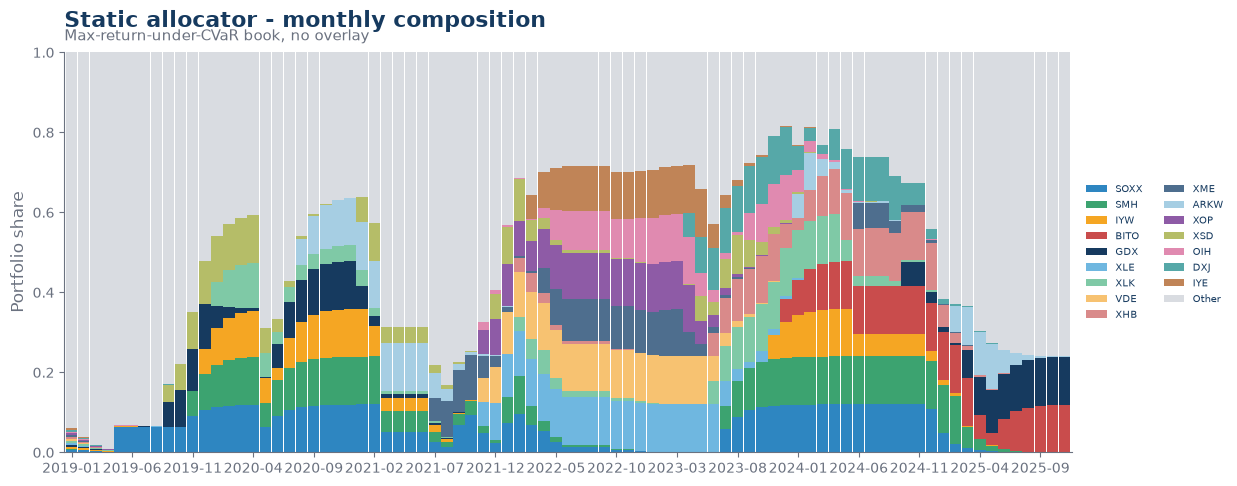

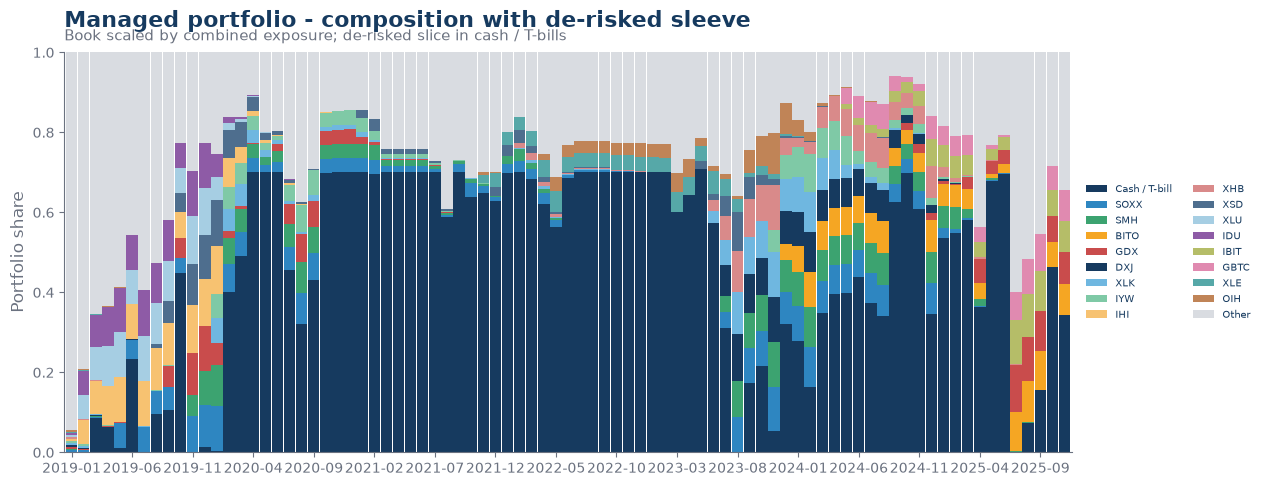

In [25]:
w_static = load_weights(PRIMARY_STATIC); w_strong = W_strong
def comp_matrix(weights, kt=None):
    months = sorted(weights.keys()); colset = sorted({t for m in months for t in weights[m].index})
    M = pd.DataFrame(0.0, index=months, columns=colset)
    for m in months:
        M.loc[m, weights[m].index] = weights[m].values
        if kt is not None: M.loc[m] *= float(kt.get(m, 1.0))
    if kt is not None: M["Cash / T-bill"] = (1.0 - M.sum(axis=1)).clip(lower=0)
    return M
def plot_comp(M, title, sub, cash="Cash / T-bill"):
    etfs = [c for c in M.columns if c != cash]
    keep = list(M[etfs].sum().sort_values(ascending=False).head(TOP_K).index); rest = [c for c in etfs if c not in keep]
    P = M[keep].copy()
    if rest: P["Other"] = M[rest].sum(axis=1)
    order = keep + (["Other"] if rest else []); cmap = {c: CAT[i % len(CAT)] for i, c in enumerate(keep)}
    if rest: cmap["Other"] = "#D9DCE1"
    if cash in M.columns: P[cash] = M[cash]; order = [cash] + order; cmap[cash] = rs.NAVY
    x = np.arange(len(P.index)); bottom = np.zeros(len(P.index)); fig, ax = plt.subplots(figsize=(13, 5.2))
    for c in order:
        ax.bar(x, P[c].values, bottom=bottom, width=0.95, color=cmap[c], label=c, linewidth=0); bottom += P[c].values
    step = max(1, len(x)//14); ax.set_xticks(x[::step]); ax.set_xticklabels([d.strftime("%Y-%m") for d in P.index[::step]])
    ax.set_xlim(-0.6, len(x)-0.4); ax.set_ylim(0, 1.001); ax.set_ylabel("Portfolio share"); ax.grid(False)
    ax.legend(ncol=2, fontsize=7.5, loc="center left", bbox_to_anchor=(1.005, 0.5)); rs.title(ax, title, sub); plt.show()

ns = pd.Series({m: int((w > 1e-9).sum()) for m, w in w_static.items()}); ns = ns[ns.index >= "2019-01-01"]
nm = pd.Series({m: int((w > 1e-9).sum()) for m, w in w_strong.items()}); nm = nm[nm.index >= "2019-01-01"]
print("Held ETFs / month:")
print(f"  Static  -> mean {ns.mean():.1f}, median {int(ns.median())}, min {ns.min()}, max {ns.max()}")
print(f"  Managed -> mean {nm.mean():.1f}, median {int(nm.median())}, min {nm.min()}, max {nm.max()}")
plot_comp(comp_matrix(w_static), "Static allocator - monthly composition", "Max-return-under-CVaR book, no overlay")
plot_comp(comp_matrix(w_strong, k_comb), "Managed portfolio - composition with de-risked sleeve",
          "Book scaled by combined exposure; de-risked slice in cash / T-bills")


## 7. Turnover

Turnover (one-way): mean 14.0%, median 13.1%, max 41.9%, zero-turnover 3/82 months, large(>=10%) 56


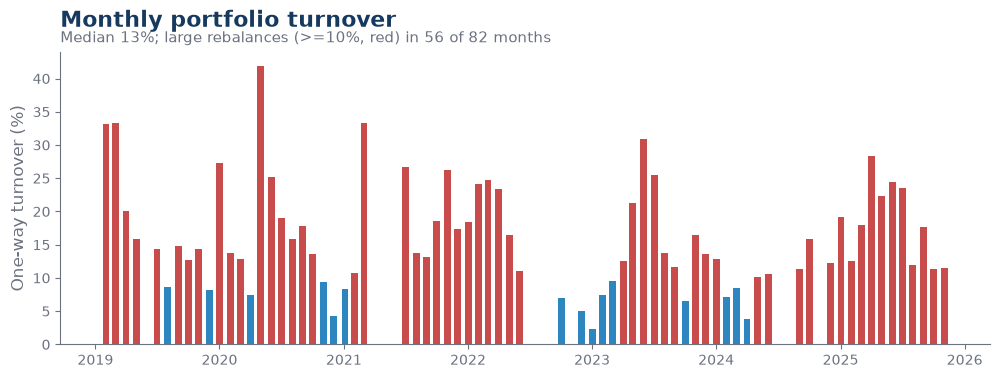

In [26]:
allm = sorted(w_strong.keys()); tn = {}
for i in range(1, len(allm)):
    if allm[i] < pd.Timestamp("2019-01-01"): continue
    a, b = w_strong[allm[i-1]], w_strong[allm[i]]; ixu = a.index.union(b.index)
    tn[allm[i]] = float(np.abs(b.reindex(ixu).fillna(0) - a.reindex(ixu).fillna(0)).sum())/2
tn = pd.Series(tn)
print(f"Turnover (one-way): mean {tn.mean()*100:.1f}%, median {tn.median()*100:.1f}%, max {tn.max()*100:.1f}%, "
      f"zero-turnover {int((tn<1e-9).sum())}/{len(tn)} months, large(>=10%) {int((tn>=0.10).sum())}")
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.bar(tn.index, tn.values*100, width=20, color=[rs.RED if v >= 0.10 else rs.BLUE for v in tn.values], linewidth=0)
ax.set_ylabel("One-way turnover (%)"); ax.grid(axis="y")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
rs.title(ax, "Monthly portfolio turnover", f"Median {tn.median()*100:.0f}%; large rebalances (>=10%, red) in {int((tn>=0.10).sum())} of {len(tn)} months")
plt.show()


## 8. Dynamic optimiser parameters

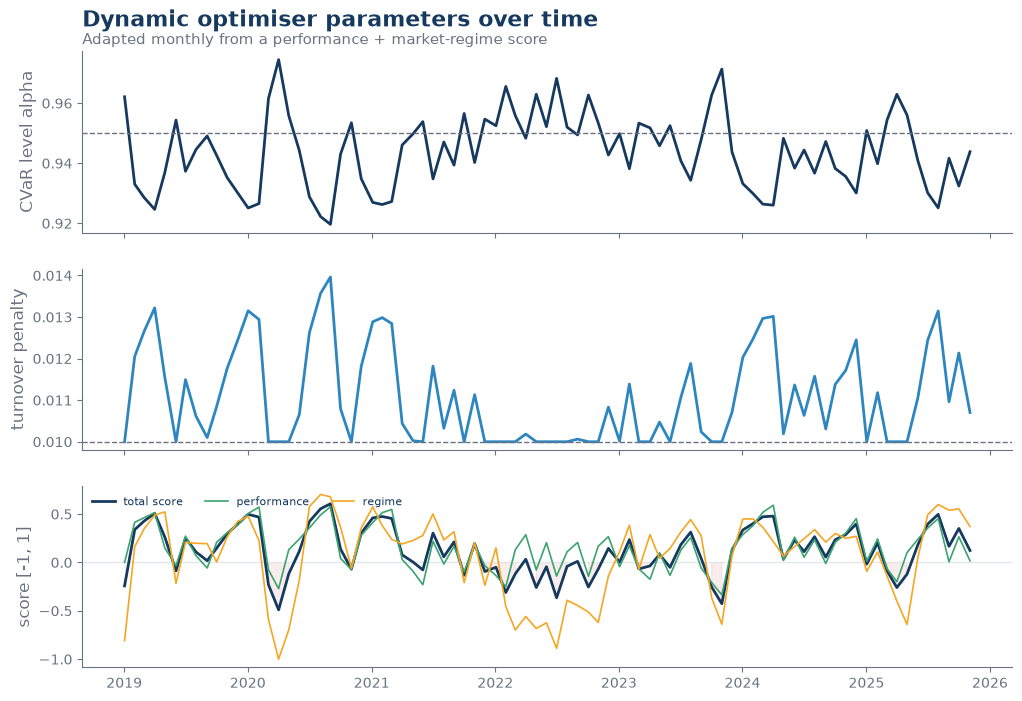

alpha range [0.920, 0.975] | lambda range [0.0100, 0.0140] | score range [-0.49, 0.61]


In [27]:
h = pd.read_csv(DATA/"main_dyn_strong"/"dynamic_parameter_history.csv"); h["date"] = pd.to_datetime(h["date"])
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].plot(h["date"], h["confidence_level"], color=rs.NAVY, lw=2); ax[0].axhline(0.95, color=rs.GREY, ls="--", lw=1)
ax[0].set_ylabel("CVaR level alpha"); rs.title(ax[0], "Dynamic optimiser parameters over time", "Adapted monthly from a performance + market-regime score")
ax[1].plot(h["date"], h["turnover_penalty"], color=rs.BLUE, lw=2); ax[1].axhline(0.01, color=rs.GREY, ls="--", lw=1); ax[1].set_ylabel("turnover penalty")
ax[2].axhline(0, color=rs.GRID, lw=1)
ax[2].plot(h["date"], h["total_score"], color=rs.NAVY, lw=2, label="total score")
ax[2].plot(h["date"], h["performance_score"], color=rs.GREEN, lw=1.2, label="performance")
ax[2].plot(h["date"], h["regime_score"], color=rs.ORANGE, lw=1.2, label="regime")
ax[2].fill_between(h["date"], 0, h["total_score"], where=h["total_score"] < 0, color=rs.RED, alpha=0.10)
ax[2].set_ylabel("score [-1, 1]"); ax[2].legend(loc="upper left", fontsize=8, ncol=3)
for a in ax: a.grid(axis="y")
ax[2].xaxis.set_major_locator(mdates.YearLocator()); ax[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()
print(f"alpha range [{h.confidence_level.min():.3f}, {h.confidence_level.max():.3f}] | "
      f"lambda range [{h.turnover_penalty.min():.4f}, {h.turnover_penalty.max():.4f}] | "
      f"score range [{h.total_score.min():.2f}, {h.total_score.max():.2f}]")
